In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\shash\Desktop\bangalore-traffic-project\data\Banglore_traffic_Dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year
df['WeekNumber'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter


In [ ]:
# for checking
print("Shape:", df.shape)
display(df.head(8))
display(df.dtypes)
print("\nMissing values (descending):")
display(df.isnull().sum().sort_values(ascending=False).head(30))


Shape: (8936, 21)


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,...,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,DayOfWeek,Month,Year,WeekNumber,Quarter
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,...,84.044600,85.403629,111,Clear,No,Saturday,January,2022,52,1
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,...,91.407038,59.983689,100,Clear,No,Saturday,January,2022,52,1
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,...,61.375541,95.466020,189,Clear,No,Saturday,January,2022,52,1
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,...,75.547092,63.567452,111,Clear,No,Saturday,January,2022,52,1
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,...,64.634762,93.155171,104,Clear,No,Saturday,January,2022,52,1
5,2022-01-01,M.G. Road,Trinity Circle,47848,34.241963,1.500000,100.000000,100.000000,3,145.696,...,61.016765,55.394571,94,Overcast,No,Saturday,January,2022,52,1
6,2022-01-01,M.G. Road,Anil Kumble Circle,36574,29.982430,1.500000,100.000000,100.000000,3,123.148,...,81.573690,90.372008,115,Clear,No,Saturday,January,2022,52,1
7,2022-01-01,Jayanagar,Jayanagar 4th Block,25379,38.455179,1.500000,79.038823,100.000000,2,100.758,...,88.120758,68.181480,92,Clear,No,Saturday,January,2022,52,1


Date                                  datetime64[ns]
Area Name                                     object
Road/Intersection Name                        object
Traffic Volume                                 int64
Average Speed                                float64
Travel Time Index                            float64
Congestion Level                             float64
Road Capacity Utilization                    float64
Incident Reports                               int64
Environmental Impact                         float64
Public Transport Usage                       float64
Traffic Signal Compliance                    float64
Parking Usage                                float64
Pedestrian and Cyclist Count                   int64
Weather Conditions                            object
Roadwork and Construction Activity            object
DayOfWeek                                     object
Month                                         object
Year                                          


Missing values (descending):


Date                                  0
Traffic Signal Compliance             0
WeekNumber                            0
Year                                  0
Month                                 0
DayOfWeek                             0
Roadwork and Construction Activity    0
Weather Conditions                    0
Pedestrian and Cyclist Count          0
Parking Usage                         0
Public Transport Usage                0
Area Name                             0
Environmental Impact                  0
Incident Reports                      0
Road Capacity Utilization             0
Congestion Level                      0
Travel Time Index                     0
Average Speed                         0
Traffic Volume                        0
Road/Intersection Name                0
Quarter                               0
dtype: int64

In [9]:
df = df.dropna(subset=['Date']).reset_index(drop=True)
print("After dropping bad dates:", df.shape)


After dropping bad dates: (8936, 21)


In [10]:
# numeric overview
display(df.describe(include='all').T)

# KPI-style single numbers
kpis = {
    'rows': len(df),
    'unique_areas': df['Area Name'].nunique() if 'Area Name' in df.columns else None,
    'total_traffic': int(df['Traffic Volume'].sum()) if 'Traffic Volume' in df.columns else None,
    'avg_speed': float(df['Average Speed'].mean()) if 'Average Speed' in df.columns else None,
    'avg_congestion': float(df['Congestion Level'].mean()) if 'Congestion Level' in df.columns else None,
}
kpis


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,8936,NaN,NaN,NaN,2023-04-22 05:25:11.548791552,2022-01-01 00:00:00,2022-08-26 00:00:00,2023-04-24 00:00:00,2023-12-17 06:00:00,2024-08-09 00:00:00,NaN
Area Name,8936,8,Indiranagar,1720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Road/Intersection Name,8936,16,100 Feet Road,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traffic Volume,8936.0,NaN,NaN,NaN,29236.04812,4233.0,19413.0,27600.0,38058.5,72039.0,13001.808801
Average Speed,8936.0,NaN,NaN,NaN,39.447427,20.0,31.775825,39.199368,46.644517,89.790843,10.707244
Travel Time Index,8936.0,NaN,NaN,NaN,1.375554,1.000039,1.242459,1.5,1.5,1.5,0.165319
Congestion Level,8936.0,NaN,NaN,NaN,80.818041,5.160279,64.292905,92.389018,100.0,100.0,23.533182
Road Capacity Utilization,8936.0,NaN,NaN,NaN,92.029215,18.739771,97.35499,100.0,100.0,100.0,16.583341
Incident Reports,8936.0,NaN,NaN,NaN,1.570389,0.0,0.0,1.0,2.0,10.0,1.420047
Environmental Impact,8936.0,NaN,NaN,NaN,108.472096,58.466,88.826,105.2,126.117,194.078,26.003618


{'rows': 8936,
 'unique_areas': 8,
 'total_traffic': 261253326,
 'avg_speed': 39.447426957306334,
 'avg_congestion': 80.81804073595616}

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: int64)

In [12]:
# columns we will attempt to impute
num_cols = [c for c in ['Traffic Volume','Average Speed','Congestion Level','Travel Time Index','Road Capacity Utilization','Pedestrian and Cyclist Count'] if c in df.columns]

# Impute median by Area Name, fallback to global median
for col in num_cols:
    if 'Area Name' in df.columns:
        df[col] = df.groupby('Area Name')[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

# Fill small categorical missing values
for cat in ['Incident Reports','Weather Conditions','Roadwork and Construction Activity','Environmental Impact','Parking Usage']:
    if cat in df.columns:
        if df[cat].dtype == 'O':
            df[cat] = df[cat].fillna('Unknown')
        else:
            df[cat] = df[cat].fillna(0)

print("Missing after imputation:")
display(df.isnull().sum().sort_values(ascending=False).head(30))


Missing after imputation:


Date                                  0
Traffic Signal Compliance             0
WeekNumber                            0
Year                                  0
Month                                 0
DayOfWeek                             0
Roadwork and Construction Activity    0
Weather Conditions                    0
Pedestrian and Cyclist Count          0
Parking Usage                         0
Public Transport Usage                0
Area Name                             0
Environmental Impact                  0
Incident Reports                      0
Road Capacity Utilization             0
Congestion Level                      0
Travel Time Index                     0
Average Speed                         0
Traffic Volume                        0
Road/Intersection Name                0
Quarter                               0
dtype: int64

In [13]:
# Monthly total traffic
monthly = df.groupby(['Year','Month'], sort=False).agg({'Traffic Volume':'sum'}).reset_index()
# To order months correctly create month number
months = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly['Month'] = pd.Categorical(monthly['Month'], categories=months, ordered=True)
monthly = monthly.sort_values(['Year','Month'])

# Weekly avg congestion
weekly = df.groupby(['Year','WeekNumber']).agg({'Traffic Volume':'sum','Congestion Level':'mean'}).reset_index()

# Area summary
area_summary = df.groupby('Area Name').agg({
    'Traffic Volume':'sum',
    'Average Speed':'mean',
    'Congestion Level':'mean',
    'Incident Reports':'sum'
}).reset_index().sort_values('Traffic Volume', ascending=False)

# show
display(monthly.head(12))
display(weekly.head(12))
display(area_summary.head(12))


,Year,Month,Traffic Volume
0,2022,January,8307469
1,2022,February,7644865
2,2022,March,9104378
3,2022,April,8006079
4,2022,May,8121208
5,2022,June,8675355
6,2022,July,8648684
7,2022,August,8773259
8,2022,September,8157725
9,2022,October,8891712


,Year,WeekNumber,Traffic Volume,Congestion Level
0,2022,1,1928790,80.392445
1,2022,2,1765236,77.111306
2,2022,3,1628417,80.521983
3,2022,4,1996348,77.979500
4,2022,5,1871900,80.758758
5,2022,6,1891087,80.899746
6,2022,7,2139790,81.135143
7,2022,8,1747859,80.065322
8,2022,9,2179097,81.927485
9,2022,10,2133185,84.467085


,Area Name,Traffic Volume,Average Speed,Congestion Level,Incident Reports
4,Koramangala,55695194,36.062629,93.985536,2519
2,Indiranagar,55529148,38.644341,87.641890,3057
5,M.G. Road,52985940,37.535189,90.579670,2799
3,Jayanagar,28857360,39.789692,76.998324,1740
1,Hebbal,25206571,40.149855,80.087244,1489
6,Whitefield,20060010,42.140866,69.054661,1202
7,Yeshwanthpur,13895755,43.447576,62.369634,796
0,Electronic City,9023348,43.661789,54.454507,431


In [14]:
import os
os.makedirs('images', exist_ok=True)


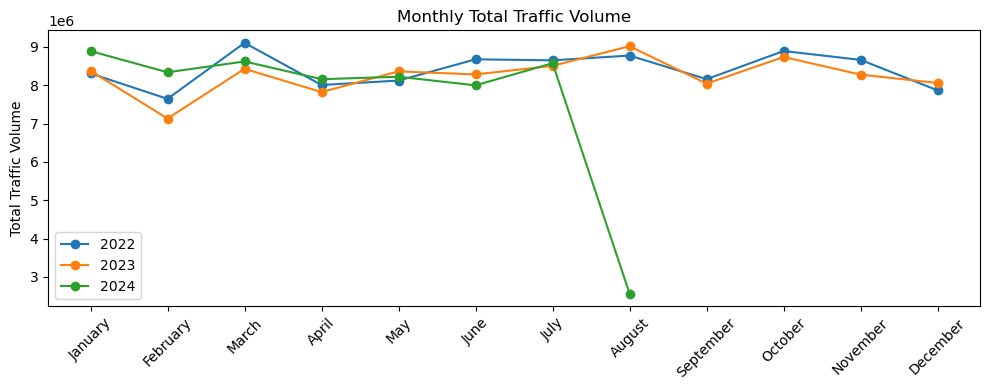

In [15]:
plt.figure(figsize=(10,4))
for year in monthly['Year'].unique():
    subset = monthly[monthly['Year']==year]
    plt.plot(subset['Month'], subset['Traffic Volume'], marker='o', label=str(year))
plt.xticks(rotation=45)
plt.title('Monthly Total Traffic Volume')
plt.ylabel('Total Traffic Volume')
plt.legend()
plt.tight_layout()
plt.savefig('images/monthly_traffic.png', dpi=150)
plt.show()


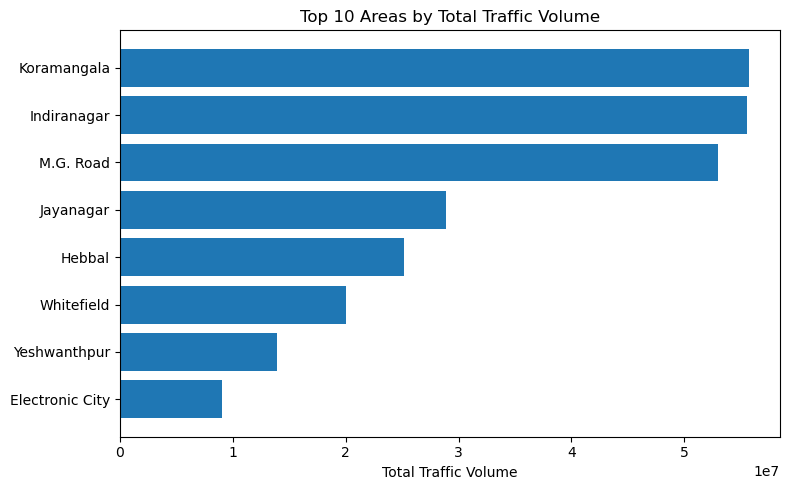

In [16]:
top_areas = area_summary.head(10).sort_values('Traffic Volume')
plt.figure(figsize=(8,5))
plt.barh(top_areas['Area Name'], top_areas['Traffic Volume'])
plt.title('Top 10 Areas by Total Traffic Volume')
plt.xlabel('Total Traffic Volume')
plt.tight_layout()
plt.savefig('images/top_areas.png', dpi=150)
plt.show()


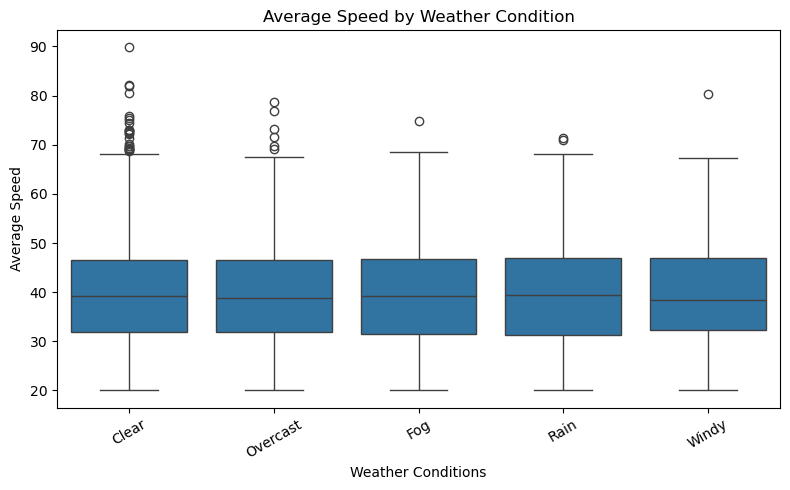

In [17]:
if 'Weather Conditions' in df.columns and 'Average Speed' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='Weather Conditions', y='Average Speed')
    plt.title('Average Speed by Weather Condition')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig('images/weather_speed_boxplot.png', dpi=150)
    plt.show()


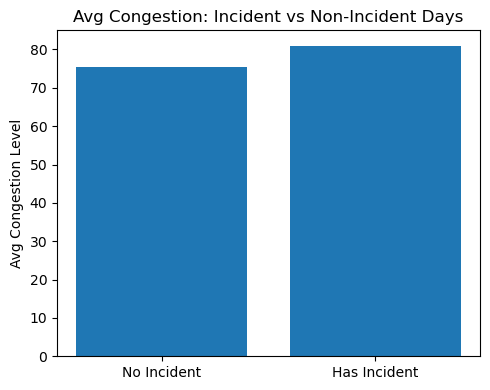

In [18]:
if 'Incident Reports' in df.columns:
    # Group by whether there was at least one incident that day (aggregate per Date)
    daily = df.groupby('Date').agg({'Incident Reports':'sum','Congestion Level':'mean'}).reset_index()
    daily['has_incident'] = daily['Incident Reports']>0
    summary_inc = daily.groupby('has_incident')['Congestion Level'].mean().reset_index()
    plt.figure(figsize=(5,4))
    plt.bar(['No Incident','Has Incident'], summary_inc['Congestion Level'])
    plt.title('Avg Congestion: Incident vs Non-Incident Days')
    plt.ylabel('Avg Congestion Level')
    plt.tight_layout()
    plt.savefig('images/incident_congestion.png', dpi=150)
    plt.show()


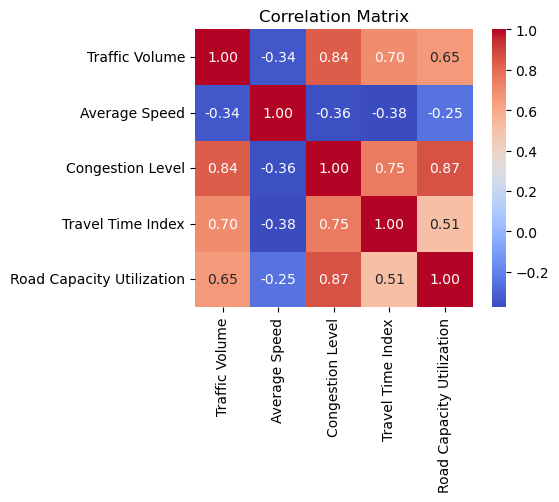

In [19]:
num_for_corr = [c for c in ['Traffic Volume','Average Speed','Congestion Level','Travel Time Index','Road Capacity Utilization'] if c in df.columns]
plt.figure(figsize=(6,5))
sns.heatmap(df[num_for_corr].corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('images/correlation_matrix.png', dpi=150)
plt.show()


In [22]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/bangalore_traffic_cleaned.csv', index=False)
print("Saved cleaned CSV:", 'data/bangalore_traffic_cleaned.csv')



Saved cleaned CSV: data/bangalore_traffic_cleaned.csv
